In [1]:
# 9.6 Q2 - Euclidean Distance + 1-NN Classification

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [3]:
df = pd.read_csv('datasets/brightness_saturation.csv')
print("Shape:", df.shape)
print(df)
print()
print("Class distribution:")
print(df['Class'].value_counts())

Shape: (7, 3)
   Brightness  Saturation Class
0          40          20   Red
1          50          50  Blue
2          60          90  Blue
3          10          25   Red
4          70          70  Blue
5          60          10   Red
6          25          80  Blue

Class distribution:
Class
Blue    4
Red     3
Name: count, dtype: int64


In [4]:
X = df[['Brightness', 'Saturation']].values
y = df['Class'].values
print("X shape:", X.shape, "y shape:", y.shape)

X shape: (7, 2) y shape: (7,)


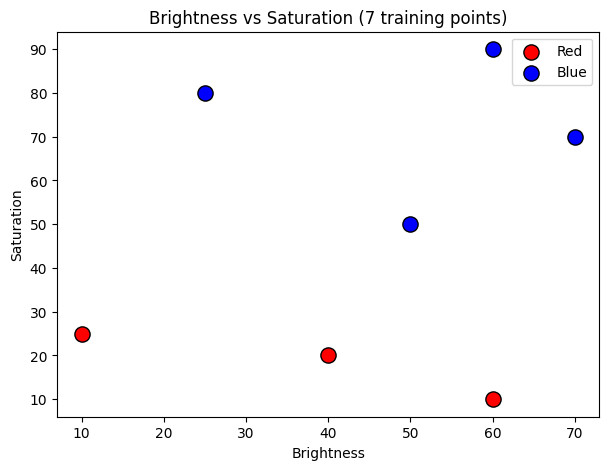

In [5]:
plt.figure(figsize=(7, 5))
colors = {'Red': 'red', 'Blue': 'blue'}
for cls in df['Class'].unique():
    sub = df[df['Class']==cls]
    plt.scatter(sub['Brightness'], sub['Saturation'],
                c=colors[cls], label=cls, s=120, edgecolors='k')
plt.xlabel('Brightness')
plt.ylabel('Saturation')
plt.title('Brightness vs Saturation (7 training points)')
plt.legend()
plt.show()

In [6]:
# Euclidean distance function

In [7]:
def euclidean(p, q):
    return np.sqrt(np.sum((np.array(p) - np.array(q)) ** 2))

print("d((0,0), (3,4)) =", euclidean((0,0), (3,4)), "(should be 5.0)")

d((0,0), (3,4)) = 5.0 (should be 5.0)


In [8]:
# Predict a new entry manually

In [9]:
new_entry = (45, 55)
print("New entry: brightness=" + str(new_entry[0]) + ", saturation=" + str(new_entry[1]))
print()
print("Euclidean distances to each training point:")
for i, row in df.iterrows():
    p = (row['Brightness'], row['Saturation'])
    d = euclidean(new_entry, p)
    print("  B=" + str(row['Brightness']).ljust(3),
          "S=" + str(row['Saturation']).ljust(3),
          row['Class'].ljust(5),
          "d=" + str(round(d, 4)))

distances = [(euclidean(new_entry, (row['Brightness'], row['Saturation'])),
             row['Class']) for _, row in df.iterrows()]
distances.sort()
nearest_class = distances[0][1]
print()
print("Closest class (1-NN):", nearest_class)

New entry: brightness=45, saturation=55

Euclidean distances to each training point:
  B=40  S=20  Red   d=35.3553
  B=50  S=50  Blue  d=7.0711
  B=60  S=90  Blue  d=38.0789
  B=10  S=25  Red   d=46.0977
  B=70  S=70  Blue  d=29.1548
  B=60  S=10  Red   d=47.4342
  B=25  S=80  Blue  d=32.0156

Closest class (1-NN): Blue


In [10]:
# Verify with scikit-learn

In [11]:
knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn.fit(X, y)
sklearn_pred = knn.predict([new_entry])[0]
print("sklearn 1-NN prediction:", sklearn_pred)
print("Manual 1-NN prediction:", nearest_class)
assert sklearn_pred == nearest_class
print("Match - manual implementation equals scikit-learn")

sklearn 1-NN prediction: Blue
Manual 1-NN prediction: Blue
Match - manual implementation equals scikit-learn
